# Training (K-Means + DBSCAN)

## 1. Load your processed data

In [3]:
import pandas as pd

df = pd.read_csv("../data/processed_data.csv")
X_scaled = df.values

## 2. Apply PCA

This helps with:
- visualization
- noise reduction

In [4]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)


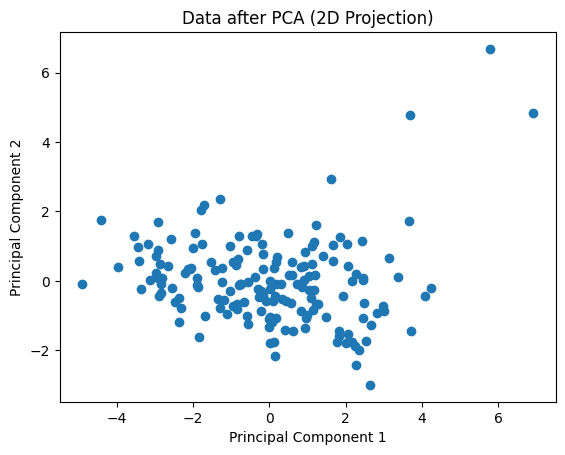

In [5]:
# Plot PCA result
plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.title("Data after PCA (2D Projection)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

## 3.Apply K-means

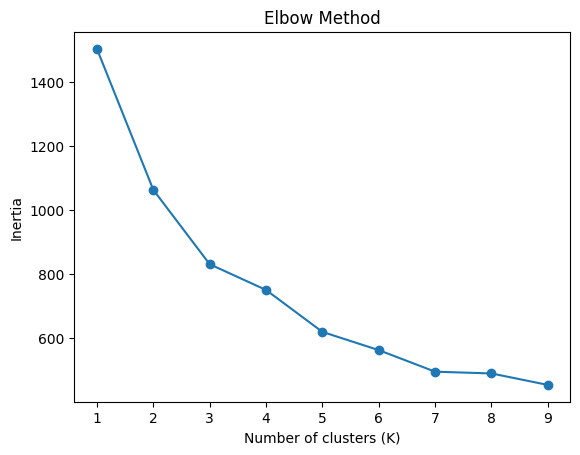

In [6]:
from sklearn.cluster import KMeans

inertia = []
K = range(1, 10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

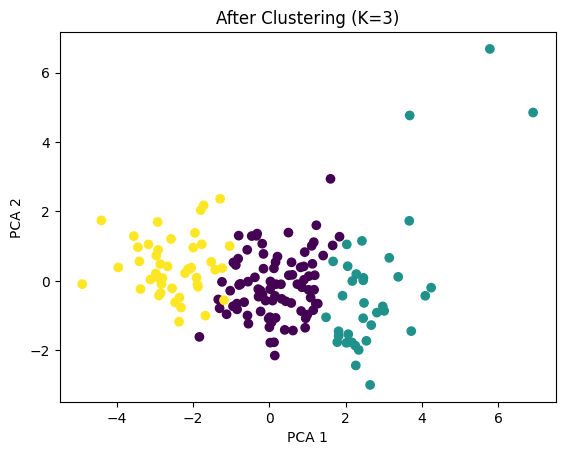

In [8]:
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis')
plt.title("After Clustering (K=3)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

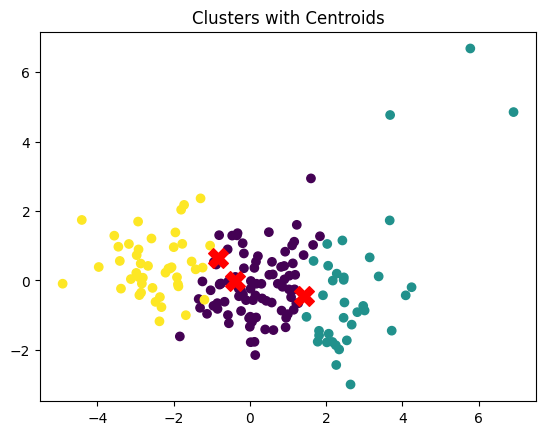

In [9]:
centers = kmeans.cluster_centers_
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, marker='X')
plt.title("Clusters with Centroids")
plt.show()

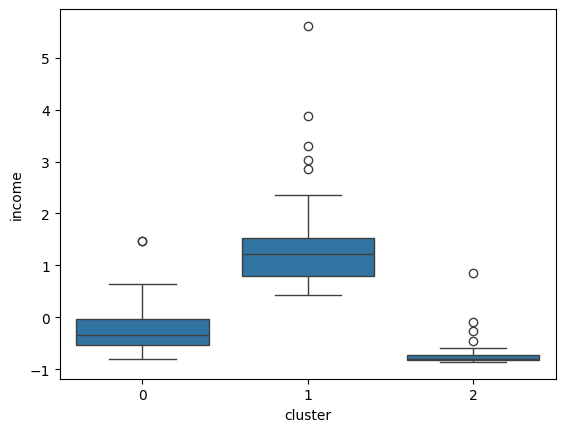

In [11]:
import seaborn as sns

df['cluster'] = clusters

sns.boxplot(x='cluster', y='income', data=df)
plt.show()

## 4.Apply DBSCAN